<a href="https://colab.research.google.com/github/simondiange/simondiange/blob/main/Prediction_model_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
! pip install pyforest

In [ ]:
from pyforest import *
lazy_imports()

['import nltk',
 'from pyspark import SparkContext',
 'from sklearn.ensemble import RandomForestRegressor',
 'from scipy import stats',
 'import tqdm',
 'from sklearn import metrics',
 'from sklearn.model_selection import KFold',
 'from sklearn.manifold import TSNE',
 'import altair as alt',
 'import statistics',
 'from sklearn.linear_model import LinearRegression',
 'from sklearn.cluster import KMeans',
 'from sklearn.decomposition import PCA',
 'from sklearn.feature_extraction.text import TfidfVectorizer',
 'import dash',
 'from sklearn.linear_model import RidgeCV',
 'from sklearn.feature_extraction.text import CountVectorizer',
 'from openpyxl import load_workbook',
 'from sklearn import svm',
 'from sklearn.ensemble import GradientBoostingClassifier',
 'import gensim',
 'import awswrangler as wr',
 'import matplotlib.pyplot as plt',
 'import fbprophet',
 'from sklearn.model_selection import GridSearchCV',
 'import bokeh',
 'from sklearn.preprocessing import OneHotEncoder',
 'import

In [ ]:
from pyforest import *
lazy_imports()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn import tree
import warnings
warnings.filterwarnings('ignore')
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

In [ ]:
# Load the dataset using pandas (lazy-imported by pyforest)
creditData = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display the first few rows of the dataframe
creditData.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
creditData.shape

(7043, 21)

In [ ]:
creditData.info

<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL             No  ...   
1             Yes                No             DSL            Yes  ...   
2             Yes                No             DSL            Yes  ...   
3              No  No phone service             DSL            Yes  ...   
4             Yes                No     Fiber optic             No  ...   
...           ...               ...             ...            ...  ...   
7038          Yes               Yes             DSL            Yes  ...   
7039          Yes               Yes     Fiber optic             No  ...   
7040           No  No phone service             DSL            Yes  ...   
7041          Yes               Yes     Fiber optic             No  ...   
7042          Yes                No     Fiber optic            Yes  ...   

     DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0                  No          No          No              No  Month-to-month   
1                 Yes          No          No              No        One year   
2                  No          No          No              No  Month-to-month   
3                 Yes         Yes          No              No        One year   
4                  No          No          No              No  Month-to-month   
...               ...         ...         ...             ...             ...   
7038              Yes         Yes         Yes             Yes        One year   
7039              Yes          No         Yes             Yes        One year   
7040               No          No          No              No  Month-to-month   
7041               No          No          No              No  Month-to-month   
7042              Yes         Yes         Yes             Yes        Two year   

     PaperlessBilling              PaymentMethod MonthlyCharges  TotalCharges  \
0                 Yes           Electronic check          29.85         29.85   
1                  No               Mailed check          56.95        1889.5   
2                 Yes               Mailed check          53.85        108.15   
3                  No  Bank transfer (automatic)          42.30       1840.75   
4                 Yes           Electronic check          70.70        151.65   
...               ...                        ...            ...           ...   
7038              Yes               Mailed check          84.80        1990.5   
7039              Yes    Credit card (automatic)         103.20        7362.9   
7040              Yes           Electronic check          29.60        346.45   
7041              Yes               Mailed check          74.40         306.6   
7042              Yes  Bank transfer (automatic)         105.65        6844.5   

     Churn  
0       No  
1       No  
2      Yes  
3       No  
4      Yes  
...    ...  
7038    No  
7039    No  
7040    No  
7041   Yes  
7042    No  

[7043 rows x 21 columns]>

In [ ]:
# Check value counts for all columns
for col in creditData.columns:
    print(f"Value counts for column '{col}':")
    display(creditData[col].value_counts())
    print("-" * 30)

Value counts for column 'customerID':


,count
customerID,
3186-AJIEK,1
7590-VHVEG,1
5575-GNVDE,1
8775-CEBBJ,1
2823-LKABH,1
...,...
6713-OKOMC,1
1452-KIOVK,1
9305-CDSKC,1


------------------------------
Value counts for column 'gender':


,count
gender,
Male,3555
Female,3488


------------------------------
Value counts for column 'SeniorCitizen':


...

------------------------------
Value counts for column 'TotalCharges':


,count
TotalCharges,
,11
20.2,11
19.75,9
20.05,8
19.9,8
...,...
130.15,1
3211.9,1
7843.55,1


------------------------------
Value counts for column 'Churn':


,count
Churn,
No,5174
Yes,1869


------------------------------


In [ ]:
# Convert the 'Contract' column to categorical data type
creditData['Contract'] = creditData['Contract'].astype('category')

# Verify the data type
display(creditData['Contract'].dtype)

CategoricalDtype(categories=['Month-to-month', 'One year', 'Two year'], ordered=False, categories_dtype=object)

In [ ]:
# Convert 'TotalCharges' to numeric, coercing errors
creditData['TotalCharges'] = pd.to_numeric(creditData['TotalCharges'], errors='coerce')

# Convert all possible columns to integer type, filling NaN with 0
for col in creditData.columns:
    # Check if the column can be converted to numeric before attempting conversion
    if pd.api.types.is_numeric_dtype(creditData[col]):
        creditData[col] = creditData[col].fillna(0).astype(int)

# Display the data types to verify the changes
display(creditData.dtypes)

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
creditData.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29,29,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56,1889,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53,108,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42,1840,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70,151,Yes


In [ ]:
creditData.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
df=creditData.drop('customerID', axis=1)
display(df.head())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29,29,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56,1889,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53,108,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42,1840,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70,151,Yes


In [ ]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype('category')
display(df.dtypes)
df.head()

,0
gender,category
SeniorCitizen,int64
Partner,category
Dependents,category
tenure,int64
PhoneService,category
MultipleLines,category
InternetService,category
OnlineSecurity,category
OnlineBackup,category


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29,29,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56,1889,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53,108,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42,1840,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70,151,Yes


<Figure size 400x300 with 0 Axes>

<Axes: xlabel='Churn', ylabel='count'>

Text(0.5, 1.0, 'Distribution of Churn')

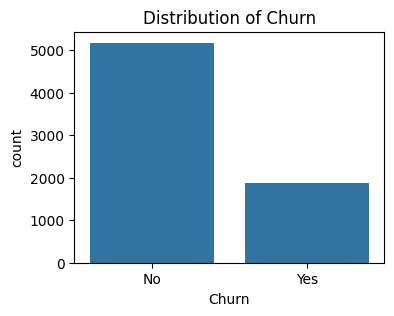

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='Contract', ylabel='count'>

Text(0.5, 1.0, 'Churn by Contract Type')

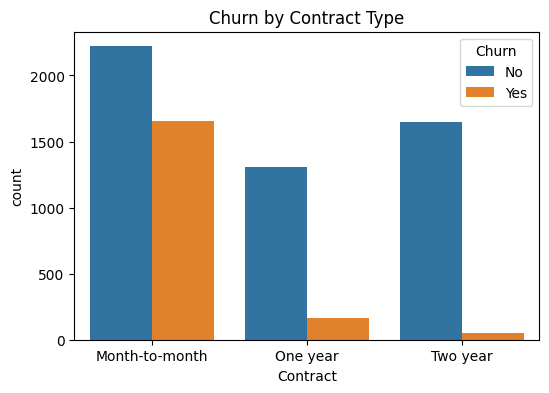

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='InternetService', ylabel='count'>

Text(0.5, 1.0, 'Churn by Internet Service Type')

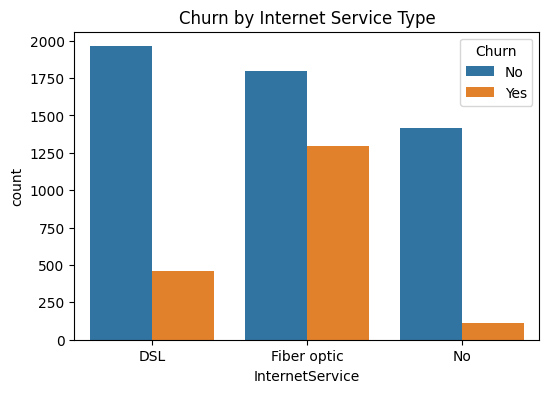

<Figure size 800x500 with 0 Axes>

<Axes: xlabel='PaymentMethod', ylabel='count'>

Text(0.5, 1.0, 'Churn by Payment Method')

([0, 1, 2, 3],
 [Text(0, 0, 'Electronic check'),
  Text(1, 0, 'Mailed check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

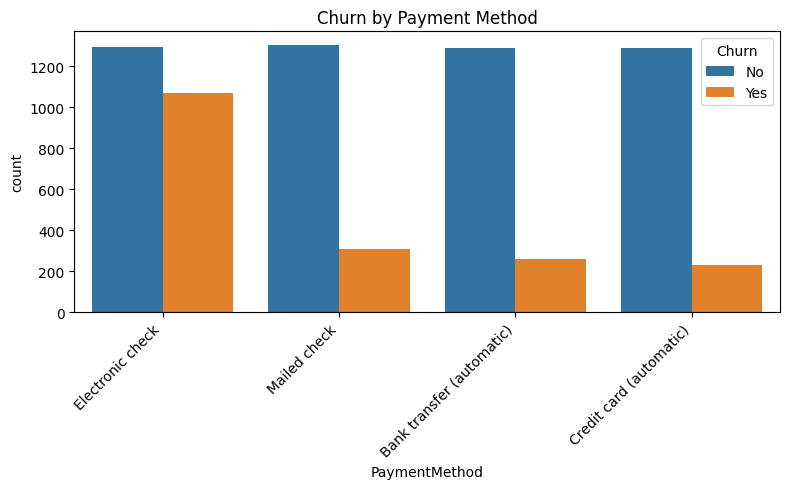

In [ ]:
# Visualize the distribution of 'Churn'
plt.figure(figsize=(4, 3))
sns.countplot(x='Churn', data=creditData)
plt.title('Distribution of Churn')
plt.show()

# Visualize the relationship between 'Churn' and 'Contract'
plt.figure(figsize=(6, 4))
sns.countplot(x='Contract', hue='Churn', data=creditData)
plt.title('Churn by Contract Type')
plt.show()

# Visualize the relationship between 'Churn' and 'InternetService'
plt.figure(figsize=(6, 4))
sns.countplot(x='InternetService', hue='Churn', data=creditData)
plt.title('Churn by Internet Service Type')
plt.show()

# Visualize the relationship between 'Churn' and 'PaymentMethod'
plt.figure(figsize=(8, 5))
sns.countplot(x='PaymentMethod', hue='Churn', data=creditData)
plt.title('Churn by Payment Method')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
creditData.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.295897,2279.265086
std,0.368612,24.559481,30.092727,2266.790864
min,0.000000,0.000000,18.000000,0.000000
25%,0.000000,9.000000,35.000000,398.000000
50%,0.000000,29.000000,70.000000,1394.000000
75%,0.000000,55.000000,89.000000,3786.500000
max,1.000000,72.000000,118.000000,8684.000000


In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29,29,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56,1889,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53,108,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42,1840,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70,151,Yes


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
display(df.dtypes)
df.isnull().sum()

,0
gender,category
SeniorCitizen,int64
Partner,category
Dependents,category
tenure,int64
PhoneService,category
MultipleLines,category
InternetService,category
OnlineSecurity,category
OnlineBackup,category


,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
df['tenure'] = df['tenure'].astype(int)
df['MonthlyCharges'] = df['MonthlyCharges'].astype(int)
df['TotalCharges'] = df['TotalCharges'].astype(int)
display(df.dtypes)
df.head(10)

,0
gender,category
SeniorCitizen,int64
Partner,category
Dependents,category
tenure,int64
PhoneService,category
MultipleLines,category
InternetService,category
OnlineSecurity,category
OnlineBackup,category


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29,29,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56,1889,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53,108,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42,1840,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70,151,Yes
5,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99,820,Yes
6,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89,1949,No
7,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29,301,No
8,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104,3046,Yes
9,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56,3487,No


In [ ]:
for col in df.columns:
    if df[col].dtype == bool:
        df[col] = df[col].astype(int)

display(df.head())
display(df.dtypes)
df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,-1.277445,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,-1.172988,-0.992780,No
1,Male,0,No,No,0.066327,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,-0.275697,-0.172179,No
2,Male,0,No,No,-1.236724,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,-0.375396,-0.957927,Yes
3,Male,0,No,No,0.514251,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),-0.740959,-0.193797,No
4,Female,0,No,No,-1.236724,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,0.189564,-0.938956,Yes


,0
gender,category
SeniorCitizen,int64
Partner,category
Dependents,category
tenure,float64
PhoneService,category
MultipleLines,category
InternetService,category
OnlineSecurity,category
OnlineBackup,category


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,-1.277445,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,-1.172988,-0.992780,No
1,Male,0,No,No,0.066327,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,-0.275697,-0.172179,No
2,Male,0,No,No,-1.236724,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,-0.375396,-0.957927,Yes
3,Male,0,No,No,0.514251,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),-0.740959,-0.193797,No
4,Female,0,No,No,-1.236724,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,0.189564,-0.938956,Yes
5,Female,0,No,No,-0.992402,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,1.153321,-0.643804,Yes
6,Male,0,No,Yes,-0.422317,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),0.820991,-0.145708,No
7,Female,0,No,No,-0.910961,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,-1.172988,-0.872778,No
8,Female,0,Yes,No,-0.177995,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,1.319486,0.338271,Yes
9,Male,0,No,Yes,1.206498,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),-0.275697,0.532833,No


In [ ]:
# Convert categorical features into dummy variables
df = pd.get_dummies(df, drop_first=True)

# Display the first few rows and the data types to verify the changes
display(df.head())
display(df.dtypes)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,-1.277445,-1.172988,-0.992780,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,0.066327,-0.275697,-0.172179,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,-1.236724,-0.375396,-0.957927,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,0.514251,-0.740959,-0.193797,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,-1.236724,0.189564,-0.938956,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


,0
SeniorCitizen,int64
tenure,float64
MonthlyCharges,float64
TotalCharges,float64
gender_Male,bool
Partner_Yes,bool
Dependents_Yes,bool
PhoneService_Yes,bool
MultipleLines_No phone service,bool
MultipleLines_Yes,bool


In [ ]:
for col in df.columns:
    if df[col].dtype == bool:
        df[col] = df[col].astype(int)

display(df.head())
display(df.dtypes)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,-1.277445,-1.172988,-0.992780,0,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,0,0.066327,-0.275697,-0.172179,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,-1.236724,-0.375396,-0.957927,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,0.514251,-0.740959,-0.193797,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,-1.236724,0.189564,-0.938956,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,1


,0
SeniorCitizen,int64
tenure,float64
MonthlyCharges,float64
TotalCharges,float64
gender_Male,int64
Partner_Yes,int64
Dependents_Yes,int64
PhoneService_Yes,int64
MultipleLines_No phone service,int64
MultipleLines_Yes,int64


In [ ]:
df.head(10)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,-1.277445,-1.172988,-0.992780,0,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,0,0.066327,-0.275697,-0.172179,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,-1.236724,-0.375396,-0.957927,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,0.514251,-0.740959,-0.193797,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,-1.236724,0.189564,-0.938956,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,1
5,0,-0.992402,1.153321,-0.643804,0,0,0,1,0,1,...,1,0,1,0,0,1,0,1,0,1
6,0,-0.422317,0.820991,-0.145708,1,0,1,1,0,1,...,1,0,0,0,0,1,1,0,0,0
7,0,-0.910961,-1.172988,-0.872778,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
8,0,-0.177995,1.319486,0.338271,0,1,0,1,0,1,...,1,0,1,0,0,1,0,1,0,1
9,0,1.206498,-0.275697,0.532833,1,0,1,1,0,0,...,0,0,0,1,0,0,0,0,0,0


In [ ]:
# Define features (X) and target (y)
X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the resulting sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (5634, 30)
Shape of X_test: (1409, 30)
Shape of y_train: (5634,)
Shape of y_test: (1409,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
rfm = RandomForestClassifier(random_state=42)

# Fit the model to the training data
rfm.fit(X_train, y_train)

print("Random Forest model trained successfully!")

RandomForestClassifier(random_state=42)

Random Forest model trained successfully!


In [ ]:
# Make predictions on the test data
y_pred =rfm.predict(X_test)

Predictions made successfully!


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Display the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7885

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.64      0.46      0.53       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.77      0.79      0.78      1409


Confusion Matrix:
[[941  95]
 [203 170]]


In [ ]:
print("Confusion Matrix Explained:")
print(f"True Positives (TP): {170} - The number of customers who actually churned and were correctly predicted as churning.")
print(f"True Negatives (TN): {941} - The number of customers who did not churn and were correctly predicted as not churning.")
print(f"False Positives (FP): {95} - The number of customers who did not churn but were incorrectly predicted as churning (Type I error).")
print(f"False Negatives (FN): {203} - The number of customers who actually churned but were incorrectly predicted as not churning (Type II error).")

Confusion Matrix Explained:
True Positives (TP): 170 - The number of customers who actually churned and were correctly predicted as churning.
True Negatives (TN): 941 - The number of customers who did not churn and were correctly predicted as not churning.
False Positives (FP): 95 - The number of customers who did not churn but were incorrectly predicted as churning (Type I error).
False Negatives (FN): 203 - The number of customers who actually churned but were incorrectly predicted as not churning (Type II error).


<Figure size 600x400 with 0 Axes>

<Axes: >

Text(0.5, 14.722222222222216, 'Predicted')

Text(45.722222222222214, 0.5, 'Actual')

Text(0.5, 1.0, 'Confusion Matrix')

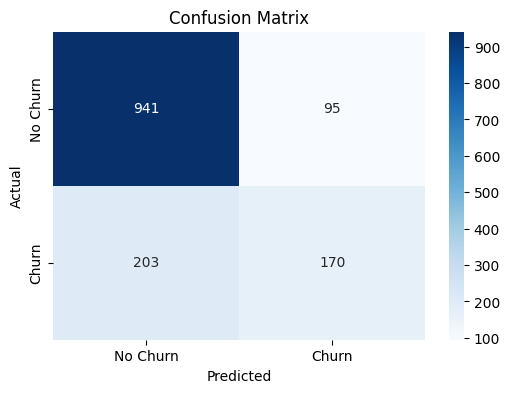

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
!pip install imblearn

In [ ]:
from imblearn.over_sampling import RandomOverSampler

# Initialize the RandomOverSampler
ros = RandomOverSampler(random_state=42)

# Apply oversampling to the training data
new_data=X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

# Display the shapes of the resampled data
print("Shape of X_resampled:", X_resampled.shape)
print("Shape of y_resampled:", y_resampled.shape)

# Display the value counts of the resampled target variable
print("\nValue counts of y_resampled:")
display(y_resampled.value_counts())

Shape of X_resampled: (8276, 30)
Shape of y_resampled: (8276,)

Value counts of y_resampled:


,count
Churn_Yes,
0,4138
1,4138


In [ ]:
X_resampled.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,-0.463037,-0.009834,-0.416153,0,0,1,1,0,0,...,0,0,0,1,1,0,0,0,0,1
1,0,0.880735,1.086855,1.257256,0,0,0,1,0,1,...,0,1,0,1,0,1,1,0,0,0
2,0,-1.277445,-1.372386,-0.995427,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
3,0,-1.155283,0.189564,-0.901014,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
4,0,-1.318165,-0.109532,-1.005574,1,0,1,1,0,1,...,0,0,0,0,0,1,1,0,0,0


In [ ]:
# Initialize and train the Random Forest model with the oversampled data
rf_model_resampled = RandomForestClassifier(random_state=42)
rf_model_resampled.fit(X_resampled, y_resampled)

print("Random Forest model trained with oversampled data successfully!")

# Make predictions on the original test data
y_pred_resampled = rf_model_resampled.predict(X_test)
print("Predictions made on test data using resampled model successfully!")

RandomForestClassifier(random_state=42)

Random Forest model trained with oversampled data successfully!
Predictions made on test data using resampled model successfully!


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Calculate the accuracy of the model
accuracy_resampled = accuracy_score(y_test, y_pred_resampled)
print(f"Accuracy (with oversampling): {accuracy_resampled:.4f}")

# Display the classification report
print("\nClassification Report (with oversampling):")
print(classification_report(y_test, y_pred_resampled))

# Display the confusion matrix
print("\nConfusion Matrix (with oversampling):")
print(confusion_matrix(y_test, y_pred_resampled))

Accuracy (with oversampling): 0.7892

Classification Report (with oversampling):
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1036
           1       0.60      0.59      0.60       373

    accuracy                           0.79      1409
   macro avg       0.73      0.72      0.73      1409
weighted avg       0.79      0.79      0.79      1409


Confusion Matrix (with oversampling):
[[893 143]
 [154 219]]


<Figure size 600x400 with 0 Axes>

<Axes: >

Text(0.5, 14.722222222222216, 'Predicted')

Text(45.722222222222214, 0.5, 'Actual')

Text(0.5, 1.0, 'Confusion Matrix (with Oversampling)')

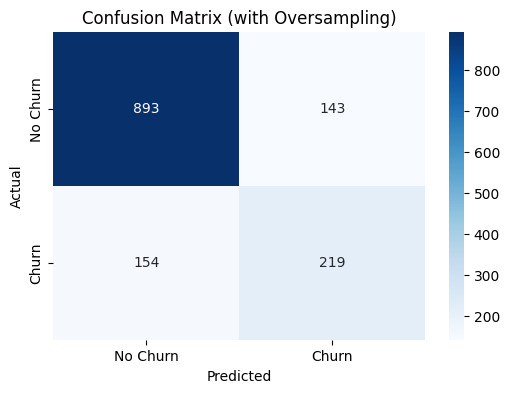

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix for the model trained with oversampled data
cm_resampled = confusion_matrix(y_test, y_pred_resampled)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm_resampled, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (with Oversampling)')
plt.show()

In [ ]:
print(f"Overall Accuracy (with oversampling): {accuracy_resampled:.2%}")

Overall Accuracy (with oversampling): 78.92%
